In [1]:
# input
metal_pred_file = "../data/sampled_pred.tsv"
model_metal_binding_file = "./tmp/sampled_metal_binding_result.tsv"
# output
fig_file = "./fig/site_perct_and_matched_perct_plddt.pdf"
fig2_file = "./fig/site_perct_and_matched_perct_rainbow.pdf"

In [2]:
import pandas as pd

df_pred = pd.read_table(metal_pred_file)
df_model = pd.read_table(model_metal_binding_file)

In [3]:
def assign_plddt_bin(x: float, bins: list = [0, 50, 70, 90, 100]):
    for idx, bin in enumerate(bins):
        if bin == 0: continue
        if x <= bin:
            return f"{bins[idx - 1]}-{bins[idx]}"
        
from itertools import combinations
import networkx as nx

def get_site(site_str: str):
    g = nx.Graph()
    sites = site_str.split(";")
    for s in sites:
        members = s.split(",")
        for (i, j) in combinations(members, 2):
            g.add_edge(i, j)
    
    result = []
    for s in nx.connected_components(g):
        result.append(sorted(list(s)))
    return result

In [4]:
records = []
for (pdb, ), df_pdb in df_model.groupby(['pdb']):
    df_pdb_ched = df_pdb[df_pdb['resi'].map(lambda x: x in {"Cys", "His", "Asp", "Glu"})]
    seq_nums = df_pdb_ched['resi_ndb_seq_can_num'].drop_duplicates().tolist()
    seq_nums.sort()
    records.append({
        "seq_id": pdb,
        "protenix_seq_num": ",".join([str(i) for i in seq_nums])
    })

def is_pro_matched(row: dict):
    pred_nums = set([i for i in row['pred_seq_num'].split(",")])
    model_nums = set([i for i in row['protenix_seq_num'].split(",")])
    inter = pred_nums & model_nums
    return 1 if len(inter) > 0 else 0

def is_merged_site_matched(row: dict):
    site_merged = []
    has_inter = []

    model_nums = set([i for i in row['protenix_seq_num'].split(",")])
    sites = get_site(row['site'])
    for site_posi in sites:
        site_num = [str(int(i) + 1) for i in site_posi]
        site_id = ",".join(site_num)
        site_merged.append(site_id)
        if len(set(site_num) & model_nums) > 0: has_inter.append(1)
        else: has_inter.append(0)
    
    return ";".join(site_merged), ",".join([str(i) for i in has_inter])

def is_resi_matched(row: dict):
    model_nums = set([i for i in row['protenix_seq_num'].split(",")])
    is_matched = []
    for i in row['pred_seq_num'].split(","):
        if i in model_nums:
            is_matched.append(1)
        else:
            is_matched.append(0)
    return ",".join([str(i) for i in is_matched])

df = pd.merge(df_pred, pd.DataFrame(records), on="seq_id")
df['plddt_bin'] = df['avg_plddt'].map(lambda x: assign_plddt_bin(x))
df['pro_matched'] = df.apply(lambda row: is_pro_matched(row), axis=1)
df['resi_matched'] = df.apply(lambda row: is_resi_matched(row), axis=1)

sites_and_matched_info = df.apply(lambda row: is_merged_site_matched(row), axis=1)
sites = [i[0] for i in sites_and_matched_info]
matched = [i[1] for i in sites_and_matched_info]
df['merged_site'] = sites
df['merged_site_matched'] = matched

# df.sort_values(by=['plddt_bin']).to_csv(matched_result, sep="\t", index=None)

In [5]:
matched = sum(df['merged_site_matched'].map(lambda x: x.count("1")))
total = sum(df['merged_site_matched'].map(lambda x: x.count(",") + 1))
print(matched)
print(total)
print(matched / total)

622
710
0.8760563380281691


In [6]:
for (bin,), df_bin in df.groupby(['plddt_bin']):
    print("protein avg plddt", bin)
    total_pro = len(df_bin)
    matched_pro = len(df_bin[df_bin['pro_matched'] == 1])
    cov_pro = matched_pro / total_pro

    total_resi = sum(df_bin['resi_matched'].map(lambda x: x.count(",") + 1))
    matched_resi = sum(df_bin['resi_matched'].map(lambda x: x.count("1")))
    cov_resi = matched_resi / total_resi

    total_site = sum(df_bin['merged_site_matched'].map(lambda x: x.count(",") + 1))
    matched_site = sum(df_bin['merged_site_matched'].map(lambda x: x.count("1")))
    cov_site = matched_site / total_site
    
    print("protein coverage ", cov_pro)
    print("site coverage ", cov_site)
    print("residue coverage ", cov_resi)

protein avg plddt 0-50
protein coverage  1.0
site coverage  0.8792270531400966
residue coverage  0.8104426787741204
protein avg plddt 50-70
protein coverage  0.9714285714285714
site coverage  0.8443804034582133
residue coverage  0.7906354515050167
protein avg plddt 70-90
protein coverage  0.9583333333333334
site coverage  0.9345794392523364
residue coverage  0.7784810126582279
protein avg plddt 90-100
protein coverage  0.9761904761904762
site coverage  0.9591836734693877
residue coverage  0.8194444444444444


In [7]:
records = []
for _, row in df.iterrows():
    num2plddt = dict(zip(
        row['pred_seq_num'].split(","),
        [float(i) for i in row['plddt'].split(",")]
    ))
    sites = row['merged_site'].split(";")
    matched = row['merged_site_matched'].split(",")
    for idx, site in enumerate(sites):
        nums = site.split(",")
        avg_site_plddt = sum([num2plddt[i] for i in nums]) / len(nums)
        is_matched = int(matched[idx])
        records.append({
            "seq_id": row["seq_id"],
            "site_plddt": avg_site_plddt,
            "is_matched": is_matched
        })
df_site = pd.DataFrame(records)
df_site['plddt_bin'] = df_site['site_plddt'].apply(lambda x: assign_plddt_bin(x))

In [8]:
df_site['is_matched'].sum() / len(df_site['is_matched'])
df_high = df_site[df_site['plddt_bin'].map(lambda x: x in {'70-90', '90-100'})]
df_high['is_matched'].sum() / len(df_high['is_matched'])

np.float64(0.8760563380281691)

np.float64(0.8841607565011821)

In [9]:
import numpy as np
import random

random.seed(6)

x_all = []
y_mean = []
x = []
y_std = []
y_all = []
for (bin, ), df_bin in df_site.groupby(by=["plddt_bin"]):
    
    seqs = sorted(list(set(df_bin['seq_id'])))
    random.shuffle(seqs)
    y_parts = []
    for rep in np.array_split(seqs, 3):
        rep_ = set(rep)
        df_ = df_bin[df_bin["seq_id"].map(lambda x: x in rep_)]
        y_parts.append(df_['is_matched'].sum() / len(df_))

    for p in y_parts:
        x_all.append(bin)
        y_all.append(p)
    x.append(bin)
    y_mean.append(sum(y_parts) / len(y_parts))
    y_std.append(np.std(y_parts, ddof=1))

x
y_mean
y_std

['0-50', '50-70', '70-90', '90-100']

[np.float64(0.8592800374006545),
 np.float64(0.877589769173119),
 np.float64(0.8666264090177135),
 np.float64(0.948134092346616)]

[np.float64(0.046986316631144366),
 np.float64(0.06620615777686228),
 np.float64(0.019401388603609373),
 np.float64(0.048760819411026037)]

In [10]:
# from "../../analyze_site_plddt.ipynb"
ratio = [0.02214349, 0.04061813, 0.24480482, 0.69243355]

(0.0, 1.0)

Text(0, 0.5, 'Share of sites')

<ErrorbarContainer object of 3 artists>

(0.0, 1.0)

Text(0, 0.5, 'Matched site percentage')

Text(0.5, 0, 'pLDDT range')

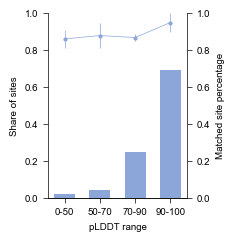

In [11]:
import matplotlib.pyplot as plt

plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")

fig, ax1 = plt.subplots(figsize=(1.8, 2.4))

# color = ["#FFB396", "#FFF099", "#A5DCF5", "#9FB9F2"]

bar_width = 0.6
bars = ax1.bar(x, ratio, width=bar_width)
# 若 bar_val 是比例（0–1），设定 0–1 刻度；若是数量，改成合适的范围与标签
# 这里给两种常用写法，二选一：
ax1.set_ylim(0, 1)                         #（占比用）0–100%
ax1.set_ylabel("Share of sites")           # 或者 "Count of sites" 如果是数量
ax1.set_yticks([i/5 for i in range(0,6)])  # 0,0.2,...,1.0

ax2 = ax1.twinx()
ax2.errorbar(x, y_mean, yerr=y_std, fmt='o-', markersize=2)  # 你的原逻辑
ax2.set_ylim(0, 1)                           # 匹配比例（0–1）
ax2.set_ylabel("Matched site percentage")

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax2.spines["left"].set_visible(False)
ax1.set_xlabel("pLDDT range")

plt.savefig(fig_file, bbox_inches="tight", transparent=True)

<Figure size 180x120 with 0 Axes>

<BarContainer object of 4 artists>

<ErrorbarContainer object of 3 artists>

([0, 1, 2, 3],
 [Text(0, 0, '0-50'),
  Text(1, 0, '50-70'),
  Text(2, 0, '70-90'),
  Text(3, 0, '90-100')])

(0.6, 1.0)

Text(0, 0.5, 'Matched site percentage')

Text(0.5, 0, 'pLDDT range')

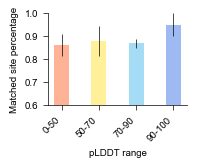

In [12]:
import matplotlib.pyplot as plt

plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")

plt.figure(figsize=(1.8, 1.2))

plt.bar(x, y_mean, width=0.4, color=["#FFB396", "#FFF099", "#A5DCF5", "#9FB9F2"])
plt.errorbar(x, y_mean, yerr=y_std, ecolor='black', linestyle='none', elinewidth=0.5)
plt.xticks(rotation=45, ha='right')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_yticks([i / 100 for i in range(60, 110, 10)])
ax.set_ylim(0.6, 1.0)

plt.ylabel("Matched site percentage")
plt.xlabel("pLDDT range")

plt.savefig(fig2_file, bbox_inches="tight", transparent=True)